In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from black_scholes.closed import implied_volatility
from heston.closed import heston_closed_price

from config.plot_settings import *

## S&P 500 volatility smile

In [36]:
spy = yf.Ticker("^SPX")

# Available expiries
print(spy.options)

expiry = '2026-06-30'
chain = spy.option_chain(expiry)
calls = chain.calls
puts  = chain.puts

S = spy.history(period='1d')['Close'].iloc[-1]
T = (pd.Timestamp(expiry) - pd.Timestamp.today()).days / 365
r = 0.05

('2026-06-01', '2026-06-02', '2026-06-03', '2026-06-04', '2026-06-05', '2026-06-08', '2026-06-09', '2026-06-10', '2026-06-11', '2026-06-12', '2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-29', '2026-06-30', '2026-07-01', '2026-07-02', '2026-07-06', '2026-07-07', '2026-07-09', '2026-07-10', '2026-07-17', '2026-07-24', '2026-07-31', '2026-08-21', '2026-08-31', '2026-09-18', '2026-09-30', '2026-10-16', '2026-10-30', '2026-11-20', '2026-12-18', '2026-12-31', '2027-01-15', '2027-02-19', '2027-03-19', '2027-03-31', '2027-04-16', '2027-05-21', '2027-06-17', '2027-09-17', '2027-12-17', '2028-12-15', '2029-12-21', '2030-12-20', '2031-12-19')


In [37]:
calls = calls[(calls['bid'] > 0) & (calls['ask'] > 0)].copy()
calls['mid'] = (calls['bid'] + calls['ask']) / 2
calls['IV'] = calls.apply(
    lambda row: implied_volatility(row['mid'], S, row['strike'], r, T, option_type="call"), axis=1
)

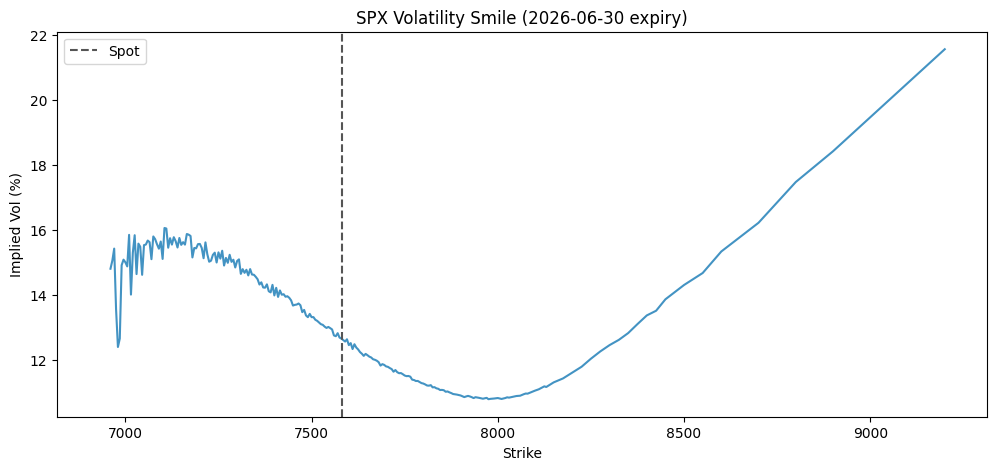

In [38]:
plt.figure(figsize=figsize2)
plt.plot(calls['strike'], calls['IV'] * 100)
plt.axvline(S, color=GRAPHITE, linestyle='--', label='Spot')
plt.xlabel('Strike'); plt.ylabel('Implied Vol (%)')
plt.title(f'SPX Volatility Smile ({expiry} expiry)')
plt.legend()
plt.savefig('../../plots/introduction/spx_vol_smile.png')
plt.show()

## Heston model

In [5]:
S0 = 100.0
T = 0.5
r = 0.05
kappa = 2.0
theta = 0.04
rho = -0.7
v0 = 0.04

In [13]:
option_type = "put"

num_strikes = 300
strikes = np.linspace(S0 * 0.6, S0 * 1.4, num_strikes)

sigmas = [0.2, 0.3, 0.4]

implied_vols = np.zeros((len(sigmas), num_strikes))
implied_vols_n = np.zeros((len(sigmas), num_strikes))

for i, sigma in enumerate(sigmas):
    for j, K in enumerate(strikes):
        price = heston_closed_price(S0, K, T, r, kappa, theta, sigma, rho, v0, option_type=option_type)
        price_n = heston_closed_price(S0, K, T, r, kappa, theta, sigma, -rho, v0, option_type=option_type)

        implied_vols[i, j] = implied_volatility(price, S0, K, r, T, option_type)
        implied_vols_n[i, j] = implied_volatility(price_n, S0, K, r, T, option_type)


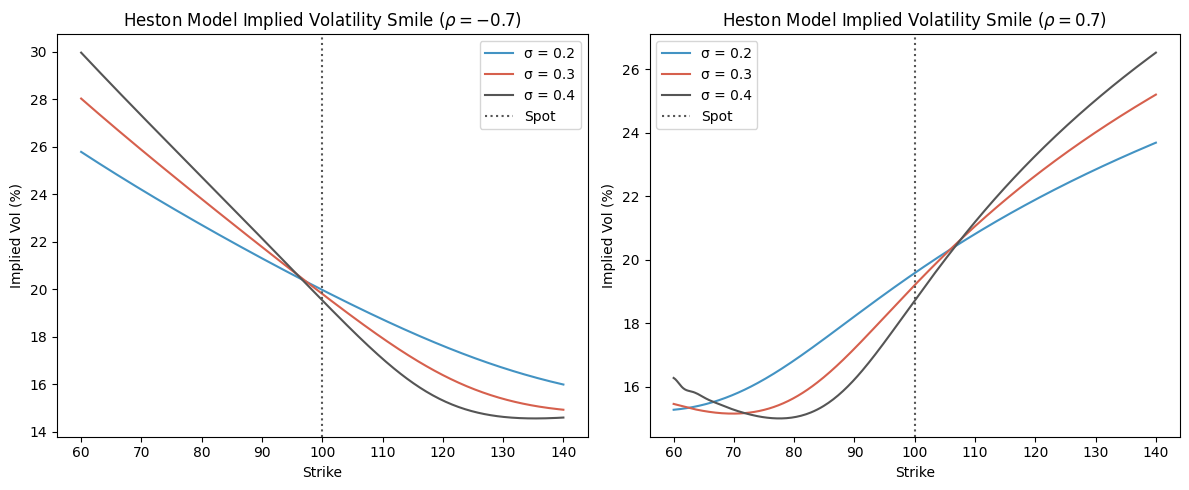

In [14]:
plt.figure(figsize=figsize2)

plt.subplot(1, 2, 1)
for i, sigma in enumerate(sigmas):
    plt.plot(strikes, np.array(implied_vols[i]) * 100, label=f'σ = {sigma}')
plt.axvline(S0, color=GRAPHITE, linestyle=':', label='Spot')
plt.xlabel('Strike')
plt.ylabel('Implied Vol (%)')
plt.title(r'Heston Model Implied Volatility Smile ($\rho = -0.7$)')
plt.legend()

plt.subplot(1, 2, 2)
for i, sigma in enumerate(sigmas):
    plt.plot(strikes, np.array(implied_vols_n[i]) * 100, label=f'σ = {sigma}')
plt.axvline(S0, color=GRAPHITE, linestyle=':', label='Spot')
plt.xlabel('Strike')
plt.ylabel('Implied Vol (%)')
plt.title(r'Heston Model Implied Volatility Smile ($\rho = 0.7$)')
plt.legend()

plt.tight_layout()
plt.savefig('../../plots/heston/vol_smile.png')
plt.show()